# **Practical Q3: Clustering using Hierarchial**

### Import Libraries

In [14]:
# Improting needed libraries

import numpy as np
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering

In [15]:
# Load data
data = pd.read_csv("Country-data.csv")
print("Shape of dataset: ", data.shape)

Shape of dataset:  (167, 10)


In [16]:
feature_names = ['child_mort', 'exports', 'health', 'imports', 'income',
                 'inflation', 'life_expec', 'total_fer', 'gdpp']

# Scale features (MinMax)
x = data[feature_names].values
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)

# Compute pairwise distances for dendrogram plotting
condensed_dist = pdist(feature_mtx, metric='euclidean')



---


# **Part (a)**
### Compare linkage methods: single, complete, average


Linkage method: single

Cluster sizes (count per cluster):
cluster_single
0    164
1      1
2      1
3      1
dtype: int64

----------------------

Part (b):
Groupby means for features for interpretation

Cluster summary (mean of features):
                child_mort     exports    health     imports        income  \
cluster_single                                                               
0                36.892073   40.546335  6.819939   46.381499  16858.615854   
1               130.000000   25.300000  5.070000   17.400000   5150.000000   
2                 2.800000  175.000000  7.770000  142.000000  91700.000000   
3               208.000000   15.300000  6.910000   64.700000   1500.000000   

                 inflation  life_expec  total_fer           gdpp  
cluster_single                                                    
0                 7.234732   70.785976   2.936037   12542.817073  
1               104.000000   60.500000   5.840000    2330.000000  
2                 3.6

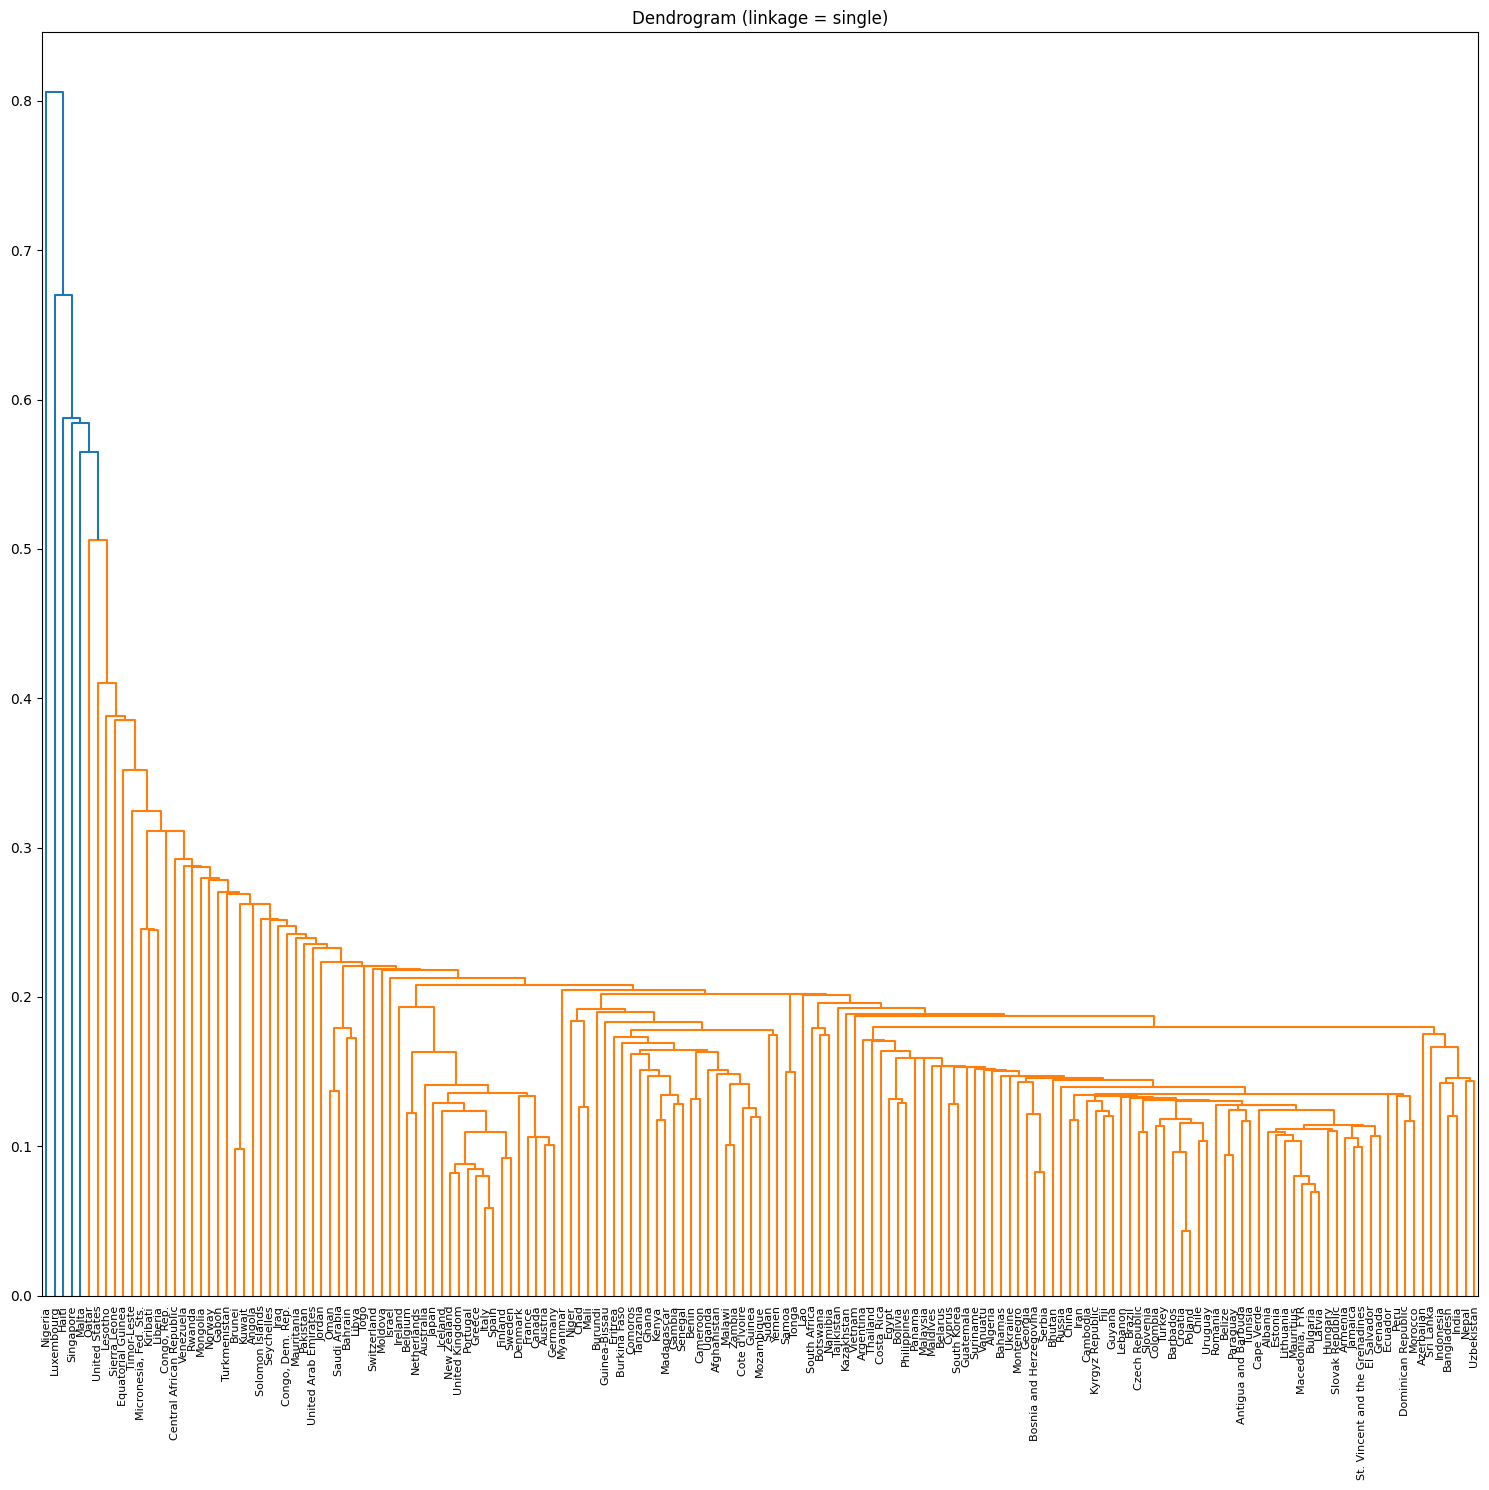


Linkage method: complete

Cluster sizes (count per cluster):
cluster_complete
0    33
1    34
2     3
3    97
dtype: int64

----------------------

Part (b):
Groupby means for features for interpretation

Cluster summary (mean of features):
                  child_mort     exports    health     imports        income  \
cluster_complete                                                               
0                 104.130303   29.376364  6.937879   46.363636   3016.757576   
1                   6.229412   46.938235  8.513235   39.414706  44502.941176   
2                   4.133333  176.000000  6.793333  156.666667  64033.333333   
3                  28.150515   38.885351  6.179794   46.294494  10911.443299   

                  inflation  life_expec  total_fer          gdpp  
cluster_complete                                                  
0                 12.358636   57.763636   5.377879   1565.696970  
1                  4.038235   79.673529   1.899412  40470.588235  
2        

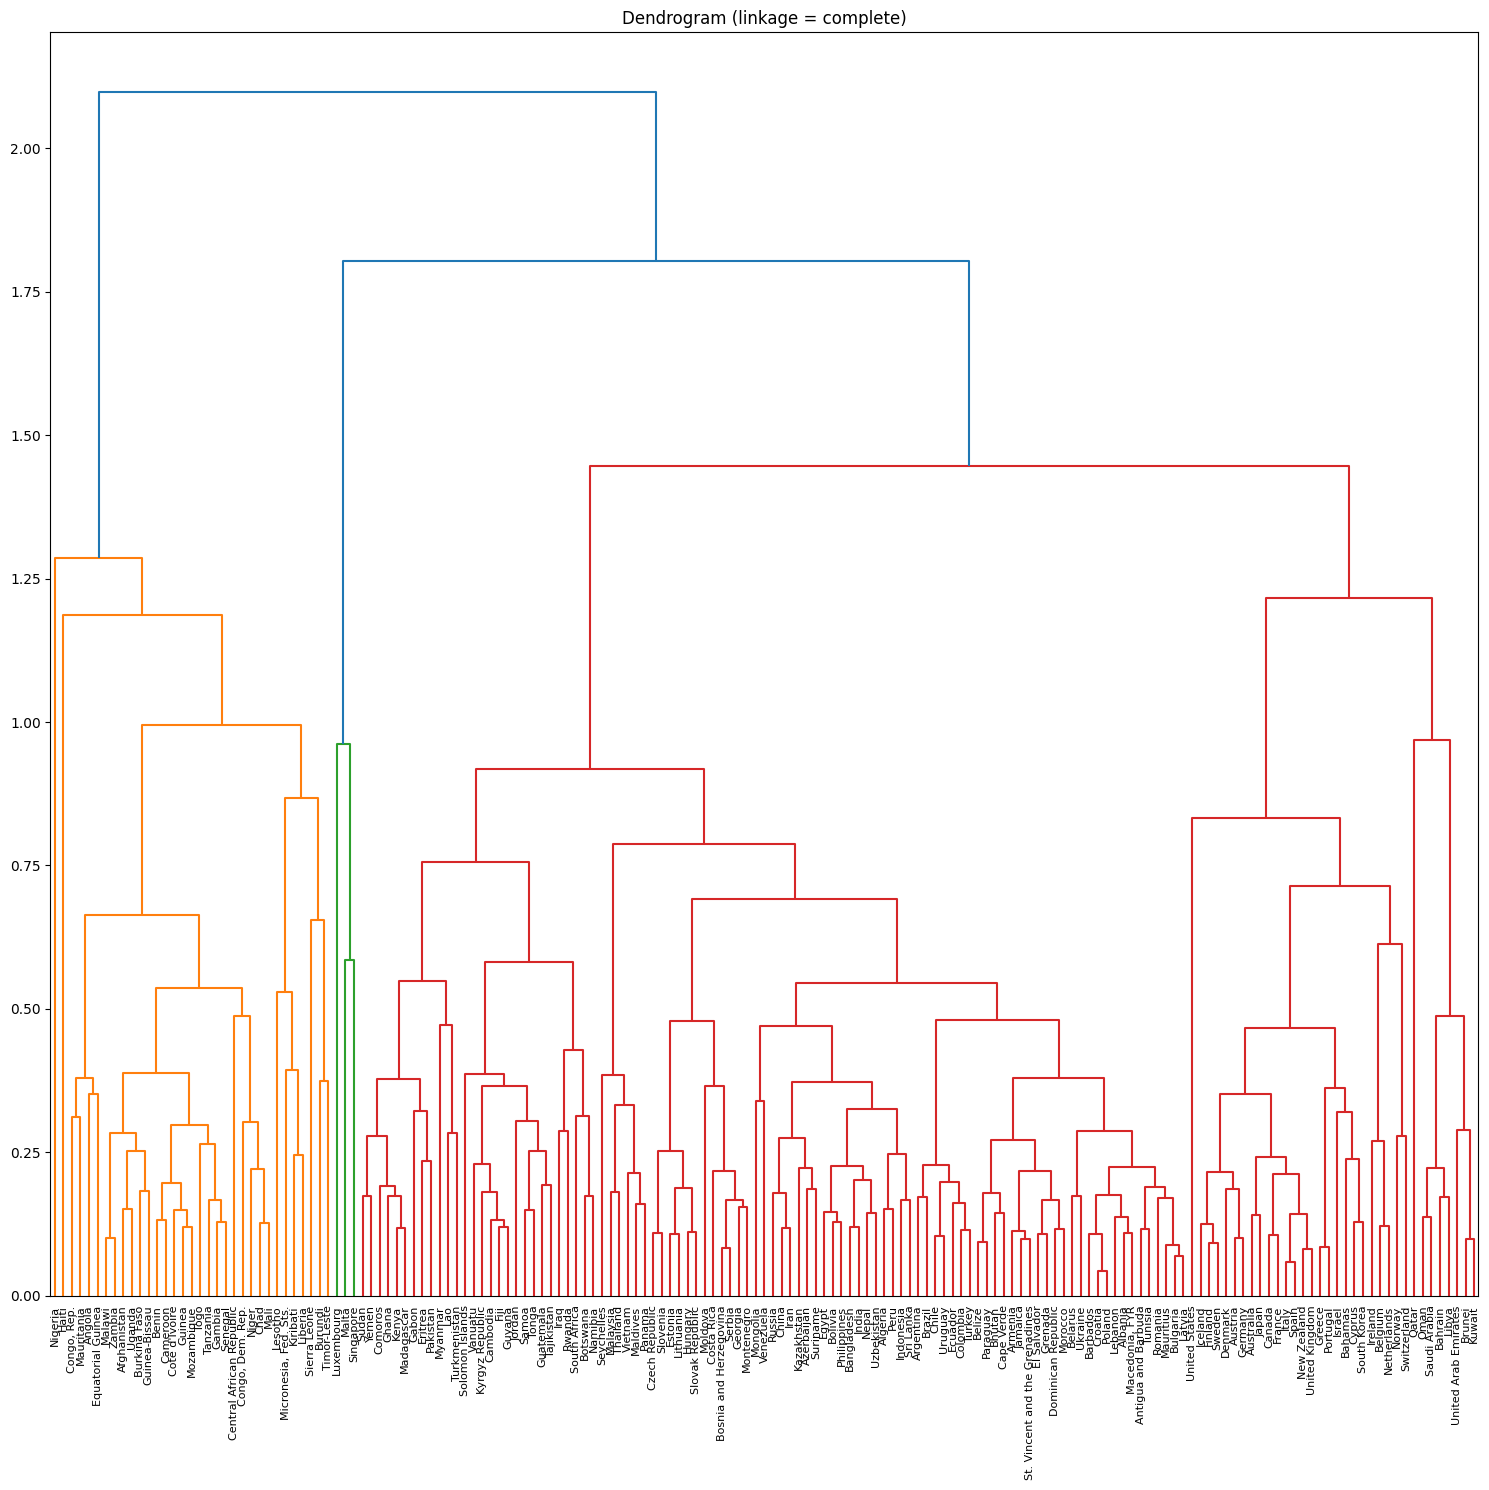


Linkage method: average

Cluster sizes (count per cluster):
cluster_average
0    162
1      3
2      1
3      1
dtype: int64

----------------------

Part (b):
Groupby means for features for interpretation

Cluster summary (mean of features):
                 child_mort     exports    health     imports        income  \
cluster_average                                                               
0                 37.288272   38.867895  6.826296   44.929419  16446.993827   
1                  4.133333  176.000000  6.793333  156.666667  64033.333333   
2                208.000000   15.300000  6.910000   64.700000   1500.000000   
3                130.000000   25.300000  5.070000   17.400000   5150.000000   

                  inflation  life_expec  total_fer          gdpp  
cluster_average                                                   
0                  7.300691   70.653704    2.95679  12279.765432  
1                  2.468000   81.433333    1.38000  57566.666667  
2            

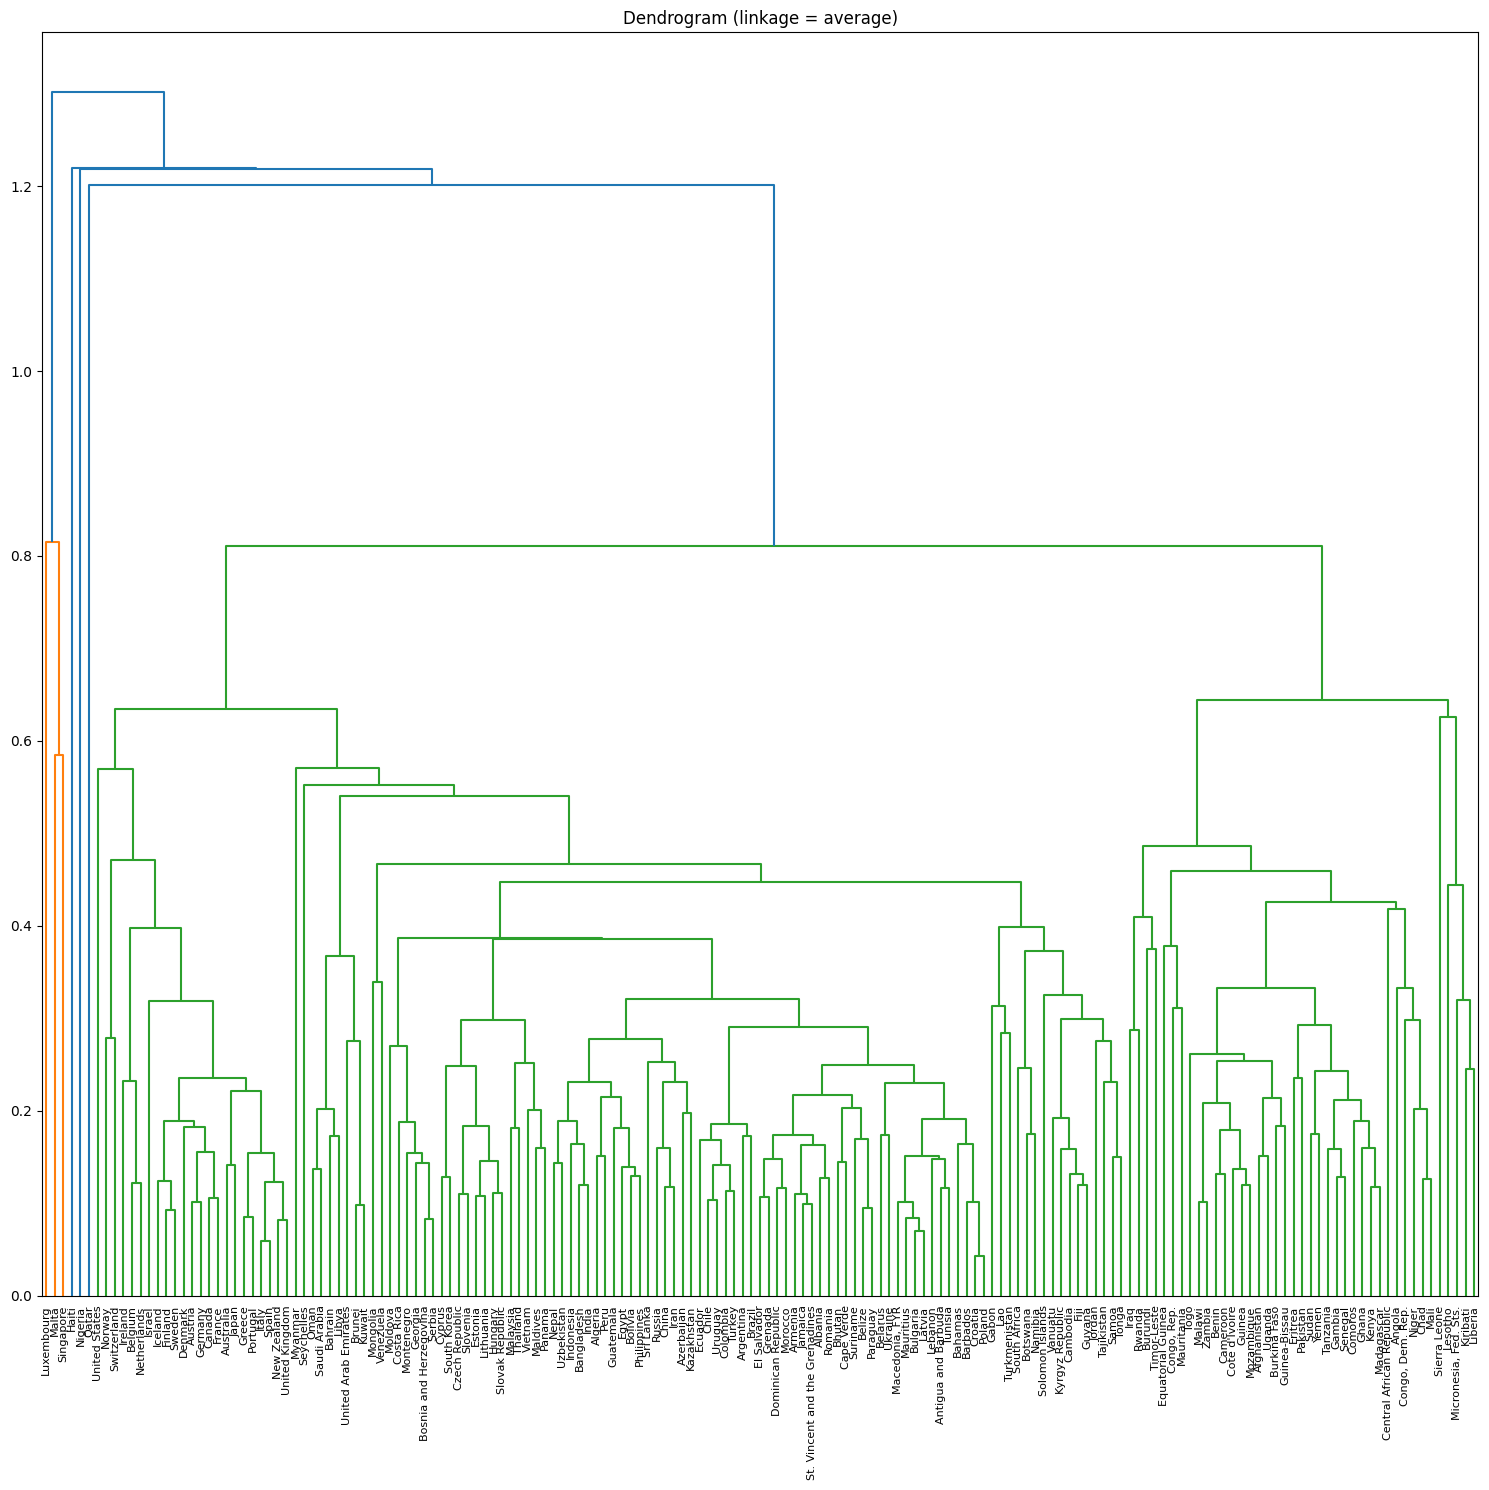

In [20]:
linkage_methods = ['single', 'complete', 'average']
n_clusters = 4

for method in linkage_methods:
    print("\n" + "="*60)
    print(f"Linkage method: {method}")
    print("="*60)

    # Fit AgglomerativeClustering on features
    agglom = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    labels = agglom.fit_predict(feature_mtx)

    # Attach cluster labels to dataset
    col = f'cluster_{method}'
    data[col] = labels

    # Cluster sizes
    sizes = data.groupby(col).size()
    print("\nCluster sizes (count per cluster):")
    print(sizes)

    # ----------------------  Part (b) ------------------------
    print("\n----------------------")
    print("\nPart (b):\nGroupby means for features for interpretation")
   

    agg_summary = data.groupby(col)[feature_names].mean()
    print("\nCluster summary (mean of features):")
    print(agg_summary)

    # Show first few countries in each cluster
    print("\nExample countries per cluster:")
    for cl in sorted(data[col].unique()):
        sample_names = data[data[col] == cl]['country'].values[:5]
        print(f" Cluster {cl}: {', '.join(sample_names)}")
    print("\n")
    

    # ----------------------  Part (c) ------------------------
    print("\n----------------------")
    print("\nPart (c):\nPlot dendrogram for this linkage")

    # Use linkage(condensed_dist, method=method).
    Z = hierarchy.linkage(condensed_dist, method=method)  # condensed distances

    plt.figure(figsize=(15,15))
    plt.title(f"Dendrogram (linkage = {method})")

        # Small custom leaf label function: show country name for leaf id
    def llf(id):
        return f"{pdf['country'].iloc[id]}"
    hierarchy.dendrogram(Z, leaf_rotation=90, leaf_font_size=8, labels=data['country'].values, color_threshold=None)
    plt.tight_layout()
    plt.show()
